<a href="https://colab.research.google.com/github/otaviau/PCVK_Genap_2026/blob/main/Modul2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRAKTIKUM PENGOLAHAN CITRA MODUL 1 LANJUTAN

**NIM**: 244107020053  
**Nama**: Otavia Ulandari <br>
**Kelas**: 3B <br>
**Prodi**: D-IV Teknik Informatika  
**Jurusan**: Teknologi Informasi

# PERTANYAAN PRAKTIKUM

##1.	Tampilkan satu citra bebas menggunakan `cv2_imshow()` dan `plt.imshow()` tanpa konversi warna apa pun. Mengapa hasilnya berbeda? Buktikan dengan mencetak nilai satu piksel yang sama dari kedua cara pembacaan tersebut.

OpenCV membaca citra dalam format warna BGR (Blue, Green, Red), sedangkan Matplotlib (plt.imshow) mengasumsikan input berada dalam format RGB (Red, Green, Blue). Karena format kanalnya tertukar, warna merah akan ditampilkan sebagai biru dan sebaliknya pada plt.imshow().

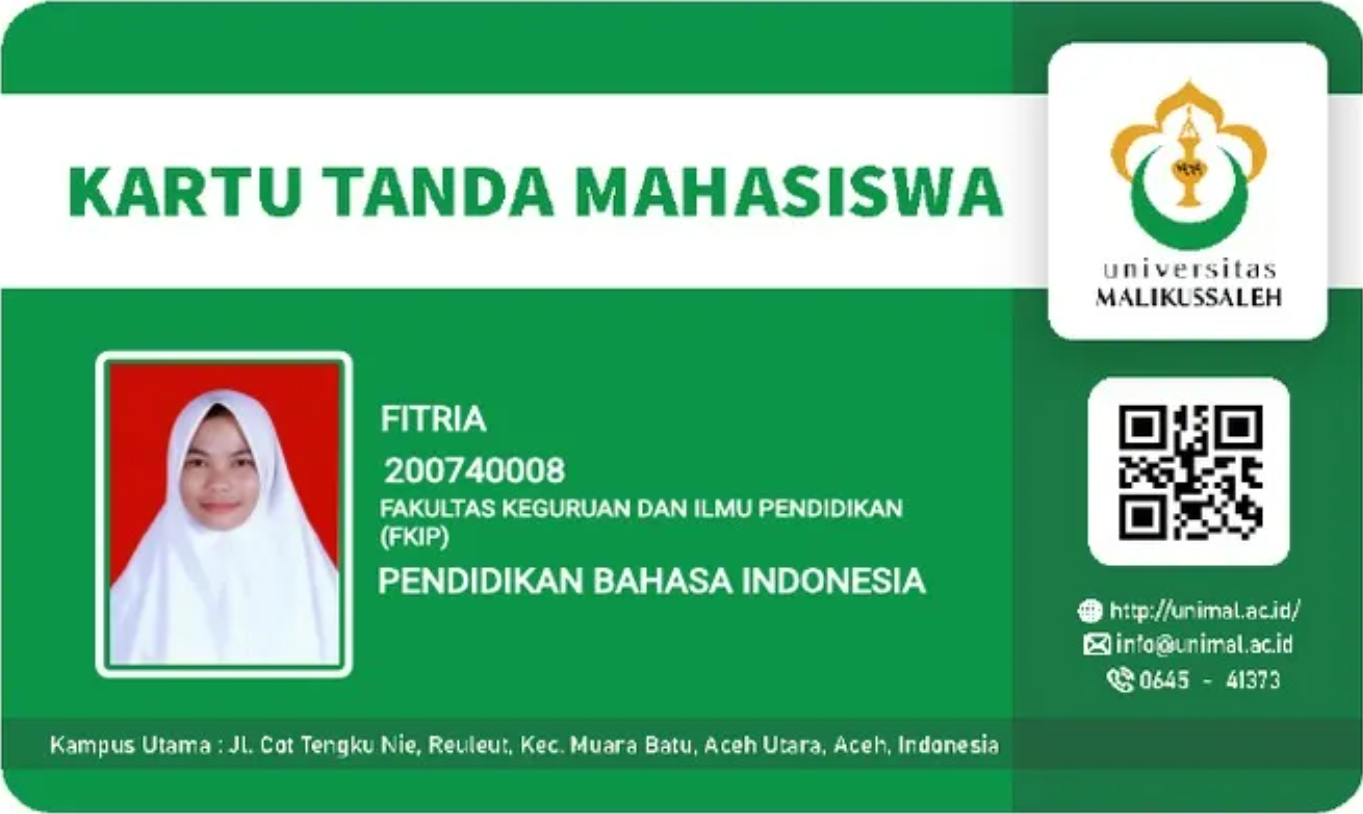

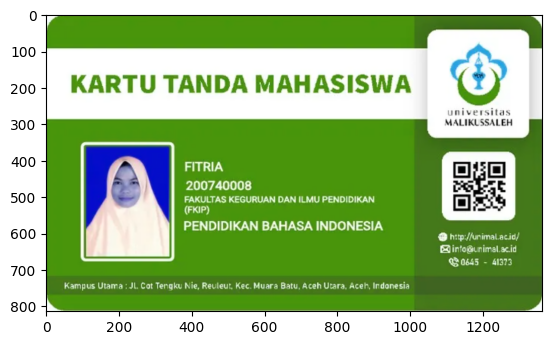

Nilai piksel pada koordinat (50, 50): [ 73 149  11]


In [2]:
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

img = cv2.imread("/content/drive/MyDrive/PCVK/Gambar/contohktm.png")

cv2_imshow(img)

plt.imshow(img)
plt.show()

print("Nilai piksel pada koordinat (50, 50):", img[50, 50])

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
##2.	Buat kanvas hitam berukuran sama dengan tipe data `int16` dan `int32`. Bandingkan `dtype`, `min()`, `max()`, dan `nbytes` keduanya. Apakah tampilannya berbeda? Apakah ukuran memorinya berbeda? Jelaskan alasannya.

Keduanya akan tampil sama persis (berwarna hitam pekat) karena semua elemen bernilai 0 dengan ukuran memori int32 dua kali lebih besar dibanding int16. Hal ini disebabkan karena tipe data int16 menggunakan 16 bit (2 byte) per elemen piksel, sedangkan int32 menggunakan 32 bit (4 byte) per elemen piksel. Karena jumlah pikselnya sama ($512 \times 512 \times 3$), memori int32 menjadi $2 \times$ lipat lebih besar.

int16 -> dtype: int16 | min: 0 | max: 0 | nbytes: 1572864 bytes
int32 -> dtype: int32 | min: 0 | max: 0 | nbytes: 3145728 bytes


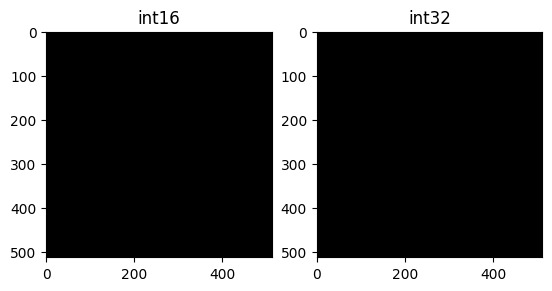

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Buat kanvas hitam 512x512
img_int16 = np.zeros((512, 512, 3), dtype=np.int16)
img_int32 = np.zeros((512, 512, 3), dtype=np.int32)

# Perbandingan statistik
print("int16 -> dtype:", img_int16.dtype, "| min:", img_int16.min(), "| max:", img_int16.max(), "| nbytes:", img_int16.nbytes, "bytes")
print("int32 -> dtype:", img_int32.dtype, "| min:", img_int32.min(), "| max:", img_int32.max(), "| nbytes:", img_int32.nbytes, "bytes")

# Tampilkan visual
plt.subplot(1, 2, 1)
plt.imshow(img_int16)
plt.title("int16")

plt.subplot(1, 2, 2)
plt.imshow(img_int32)
plt.title("int32")

plt.show()

---
##3. Apa kegunaan baris from google.colab.patches import cv2_imshow, dan mengapa cv2.imshow() bawaan OpenCV tidak dapat dipakai di Google Colab?

Fungsi `cv2_imshow` disediakan khusus oleh tim Google Colab untuk menampilkan citra OpenCV secara langsung di dalam sel buku catatan (inline output notebook). Fungsi cv2.imshow() standar bawaan OpenCV dirancang untuk membuka jendela GUI lokal (pop-up window) menggunakan pustaka seperti HighGUI/X11, oleh karena itu OpenCV tidak dapat dipakai di Google Colab

---
##4.	Citra yang dibaca dengan `skimage.io.imread()` ditampilkan berdampingan dengan hasil `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` atas citra yang sama. Manakah yang menampilkan warna sebenarnya, dan manakah yang kanalnya tertukar? Buktikan dengan nilai piksel, bukan dengan pengamatan visual saja.

Keduanya menampilkan warna sebenarnya secara akurat dan tidak ada yang tertukar di antara kedua hasil tersebut.

In [4]:
import cv2
from skimage import io
import matplotlib.pyplot as plt

path = "/content/drive/MyDrive/PCVK/Gambar/contohktm.png"

# Baca dengan skimage & cv2
img_skimage = io.imread(path)
img_cv2_rgb = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)

# Bukti Nilai Piksel
print("Nilai piksel skimage (50,50):", img_skimage[50, 50])
print("Nilai piksel cv2_rgb  (50,50):", img_cv2_rgb[50, 50])

Nilai piksel skimage (50,50): [ 11 149  73]
Nilai piksel cv2_rgb  (50,50): [ 11 149  73]


---
##5.	Setelah citra ditampilkan dengan figsize yang jauh lebih besar, apakah nilai img.shape ikut berubah? Jelaskan perbedaan antara mengubah ukuran citra dan mengubah ukuran tampilan.

Tidak, nilai img.shape tetap sama persis sebelum dan sesudah menggunakan figsize. Mengubah ukuran citra `(cv2.resize)` adalah memodifikasi struktur matriks array secara matematis, sedangkan mengubah ukuran tampilan `(figsize)` hanyalah mengatur skala dimensi kanvas atau bingkai grafik Matplotlib saat dirender di layar.